In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv(r"C:\Users\Brithi S\Downloads\supermarket_analysis.csv")

In [6]:
df.head()

,Date,Product,Category,Quantity,Unit_Price,Total_Sales,Season
0,01-01-2025,Rice,Grocery,10,60,600,Winter
1,02-01-2025,Milk,Dairy,20,30,600,Winter
2,03-01-2025,Bread,Bakery,15,40,600,Winter
3,04-01-2025,Juice,Beverage,25,50,1250,Winter
4,05-01-2025,Soap,Personal Care,18,35,630,Winter


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         28 non-null     str  
 1   Product      28 non-null     str  
 2   Category     28 non-null     str  
 3   Quantity     28 non-null     int64
 4   Unit_Price   28 non-null     int64
 5   Total_Sales  28 non-null     int64
 6   Season       28 non-null     str  
dtypes: int64(3), str(4)
memory usage: 1.7 KB


In [8]:
df.describe()

,Quantity,Unit_Price,Total_Sales
count,28.000000,28.000000,28.000000
mean,23.785714,45.000000,1037.142857
std,6.778819,19.051587,491.911292
min,10.000000,20.000000,440.000000
25%,19.500000,30.000000,667.500000
50%,24.000000,40.000000,870.000000
75%,28.000000,60.000000,1290.000000
max,40.000000,80.000000,2240.000000


In [9]:
print(df.isnull().sum())

Date           0
Product        0
Category       0
Quantity       0
Unit_Price     0
Total_Sales    0
Season         0
dtype: int64


In [10]:
df = df.drop_duplicates()

In [11]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [12]:
print(df.dtypes)

Date           datetime64[us]
Product                   str
Category                  str
Quantity                int64
Unit_Price              int64
Total_Sales             int64
Season                    str
dtype: object


In [13]:
product_sales = df.groupby("Product")["Total_Sales"].sum()
print(product_sales)

Product
Biscuits    2240
Bread       3120
Juice       6500
Milk        3090
Rice        3900
Soap        3150
Tea         7040
Name: Total_Sales, dtype: int64


In [14]:
category_sales = df.groupby("Category")["Total_Sales"].sum()
print(category_sales)

Category
Bakery            3120
Beverage          6500
Dairy             3090
Grocery          10940
Personal Care     3150
Snacks            2240
Name: Total_Sales, dtype: int64


In [15]:
season_sales = df.groupby("Season")["Total_Sales"].sum()
print(season_sales)

Season
Autumn    9120
Spring    6690
Summer    7830
Winter    5400
Name: Total_Sales, dtype: int64


In [16]:
X = df[["Quantity", "Unit_Price"]]
y = df["Total_Sales"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = model.predict(X_test)
print(y_pred)

[ 651.6652248  1000.81608944  741.38861054 1314.86539054  753.10076573
  550.22968387]


In [20]:
future_sale = model.predict([[40, 50]])
print("Predicted Future Sale:", future_sale[0])

Predicted Future Sale: 1919.5396823500516


c:\Users\Brithi S\Desktop\MLTP_AU\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


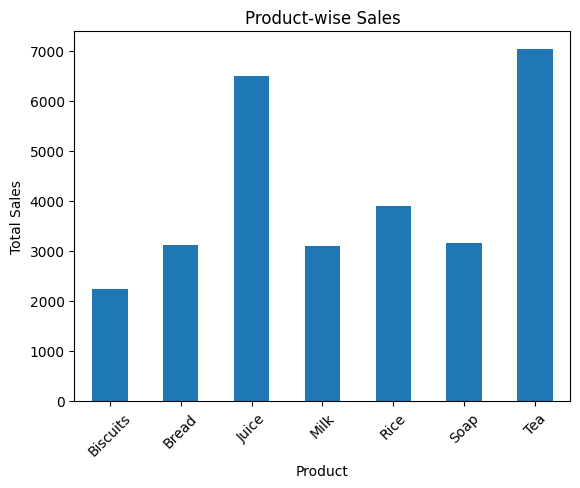

In [21]:
product_sales.plot(kind="bar")
plt.title("Product-wise Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

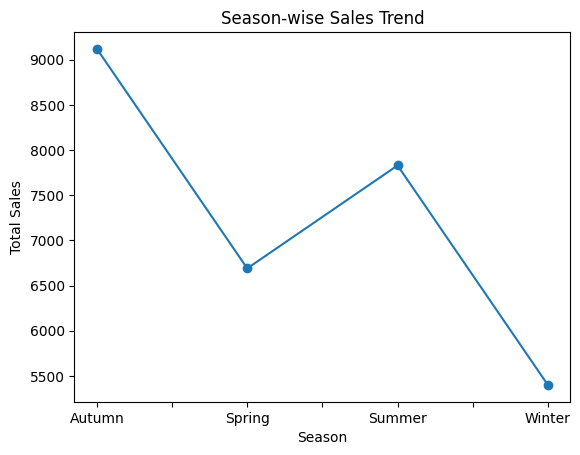

In [22]:
season_sales.plot(kind="line", marker="o")
plt.title("Season-wise Sales Trend")
plt.xlabel("Season")
plt.ylabel("Total Sales")
plt.show()

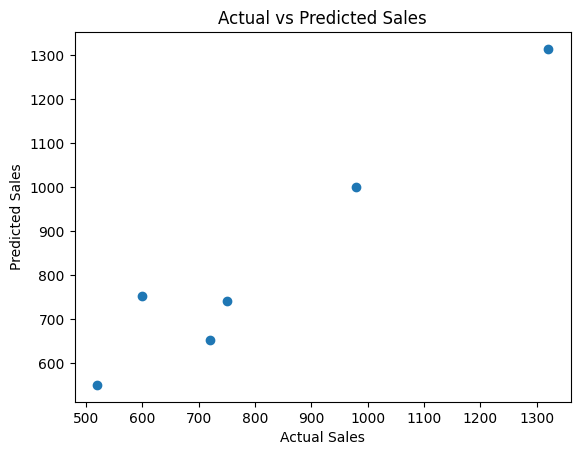

In [23]:
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()